# Outdoor Flight Data Extraction from Betaflight Blackbox Logs

This notebook extracts and analyzes flight data from Betaflight blackbox CSV exports.

**Workflow:**
1. Load Betaflight blackbox CSV file
2. Parse header metadata and identify data columns
3. Extract key flight parameters (time, motors, attitude, etc.)
4. Compute derived quantities (average RPM, pitch angle, etc.)
5. Export processed data for analysis and plotting

## 1. Import Required Libraries

## 0. Install Required Packages

Install the AHRS library for attitude estimation.

In [516]:
%pip install ahrs


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [517]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from ahrs.filters import Mahony
from ahrs.common.orientation import q2euler

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

## 2. Configuration

In [518]:
# File paths
log_dir = Path('../logs/outdoor')
output_dir = Path('./data/outdoor')
output_dir.mkdir(parents=True, exist_ok=True)

# Get all CSV files from the outdoor logs folder
log_files = sorted(log_dir.glob('*.csv'))

print(f"Log directory: {log_dir}")
print(f"Output directory: {output_dir}")
print(f"Found {len(log_files)} CSV files:")
for i, file in enumerate(log_files, 1):
    print(f"  {i}. {file.name}")

# Select which file to process (change this index to process different files)
file_index = 1  # good: 0, 1, 
log_file = log_files[file_index]

# Time range for analysis and export (in seconds)
time_start = 3
time_end = 13

print(f"\nProcessing: {log_file.name}")
print(f"Analysis time range: {time_start}s to {time_end}s")

Log directory: ../logs/outdoor
Output directory: data/outdoor
Found 7 CSV files:
  1. 10mps_LOG00008.BFL.csv
  2. 10mps_LOG00010.BFL.csv
  3. 11mps_turn_LOG00012.BFL.csv
  4. 12mps_LOG00006.BFL.csv
  5. 16mps_LOG00009.BFL.csv
  6. 16mps_LOG00011.BFL.csv
  7. 8mps_LOG00005.BFL.csv

Processing: 10mps_LOG00010.BFL.csv
Analysis time range: 3s to 13s


## 3. Parse Betaflight Blackbox CSV

Betaflight blackbox CSV files have a header section with metadata, followed by the actual flight data.

In [519]:
def parse_betaflight_csv(filepath):
    """
    Parse Betaflight blackbox CSV file.
    
    Returns:
        metadata: dict of header information
        column_names: list of column names
        data: pandas DataFrame with flight data
    """
    metadata = {}
    column_names = []
    
    # Read file to find where data starts
    with open(filepath, 'r') as f:
        lines = f.readlines()
    
    # Find the start of data (first line that starts with a number)
    data_start = 0
    for i, line in enumerate(lines):
        # Parse metadata from header
        if line.startswith('"') and ',' in line:
            parts = line.strip().split(',')
            if len(parts) >= 2:
                key = parts[0].strip('"')
                value = parts[1].strip('"')
                metadata[key] = value
                
                # Check if this is the column header line (contains "loopIteration")
                if key == 'loopIteration':
                    column_names = [p.strip('"') for p in parts]
                    data_start = i + 1  # Data starts on next line
                    break
        elif line[0].isdigit() and not column_names:
            # Data without explicit headers
            data_start = i
            break
    
    print(f"Metadata entries: {len(metadata)}")
    print(f"Column names found: {len(column_names)}")
    print(f"Data starts at line: {data_start}")
    
    # Read the data portion
    if column_names:
        data = pd.read_csv(filepath, skiprows=data_start, header=None, names=column_names)
    else:
        data = pd.read_csv(filepath, skiprows=data_start, header=None)
    
    print(f"Data shape: {data.shape}")
    
    return metadata, column_names, data

In [520]:
# Parse the log file
metadata, column_names, raw_data = parse_betaflight_csv(log_file)

# Display some metadata
print("\n=== Key Metadata ===")
for key in ['firmwareVersion', 'Log start datetime', 'Firmware revision', 'dshot_bidir', 'motor_poles']:
    if key in metadata:
        print(f"{key}: {metadata[key]}")

# Display some column names
print(f"\n=== Column Names ({len(column_names)} total) ===")
print(f"First 10: {column_names[:10]}")
rpm_cols = [col for col in column_names if 'RPM' in col]
print(f"RPM columns: {rpm_cols}")

Metadata entries: 151
Column names found: 70
Data starts at line: 151
Data shape: (15931, 70)

=== Key Metadata ===
firmwareVersion: 4.5.2
Log start datetime: 2025-11-07T12:28:53.004+00:00
Firmware revision: Betaflight 4.5.2 (024f8e13d) STM32H743
dshot_bidir: 1
motor_poles: 14

=== Column Names (70 total) ===
First 10: ['loopIteration', 'time', 'axisP[0]', 'axisP[1]', 'axisP[2]', 'axisI[0]', 'axisI[1]', 'axisI[2]', 'axisD[0]', 'axisD[1]']
RPM columns: ['eRPM[0]', 'eRPM[1]', 'eRPM[2]', 'eRPM[3]']
Data shape: (15931, 70)

=== Key Metadata ===
firmwareVersion: 4.5.2
Log start datetime: 2025-11-07T12:28:53.004+00:00
Firmware revision: Betaflight 4.5.2 (024f8e13d) STM32H743
dshot_bidir: 1
motor_poles: 14

=== Column Names (70 total) ===
First 10: ['loopIteration', 'time', 'axisP[0]', 'axisP[1]', 'axisP[2]', 'axisI[0]', 'axisI[1]', 'axisI[2]', 'axisD[0]', 'axisD[1]']
RPM columns: ['eRPM[0]', 'eRPM[1]', 'eRPM[2]', 'eRPM[3]']


## 4. Extract Time and Motor RPM Data

The Betaflight blackbox includes direct motor RPM measurements (eRPM) when bidirectional DShot is enabled.

In [521]:
# Convert time to seconds (relative to start)
if 'time' in raw_data.columns:
    raw_data['time_s'] = (raw_data['time'] - raw_data['time'].iloc[0]) / 1e6
    print(f"Flight duration: {raw_data['time_s'].iloc[-1]:.2f} seconds")
else:
    print("Warning: time column not found")

# Extract motor RPM data
# eRPM (electrical RPM) needs conversion to mechanical RPM
# Mechanical RPM = eRPM * 100 / (motor_poles / 2)
# The division by 2 is because motor_poles refers to pole pairs
motor_poles = int(metadata.get('motor_poles', 14))
pole_pairs = motor_poles / 2  # 14 poles = 7 pole pairs
print(f"\nMotor poles: {motor_poles}")
print(f"Pole pairs: {pole_pairs}")

rpm_cols = ['eRPM[0]', 'eRPM[1]', 'eRPM[2]', 'eRPM[3]']
if all(col in raw_data.columns for col in rpm_cols):
    for i, col in enumerate(rpm_cols):
        # eRPM * 100 gives electrical RPM, divide by pole pairs to get mechanical RPM
        raw_data[f'motor{i+1}_rpm'] = raw_data[col] * 100 / pole_pairs
    
    raw_data['motor_avg_rpm'] = raw_data[['motor1_rpm', 'motor2_rpm', 'motor3_rpm', 'motor4_rpm']].mean(axis=1)
    
    print(f"\nMotor RPM extracted successfully")
    print(f"Average RPM range: {raw_data['motor_avg_rpm'].min():.0f} to {raw_data['motor_avg_rpm'].max():.0f}")
    print(f"Mean: {raw_data['motor_avg_rpm'].mean():.0f} RPM")
else:
    print("Warning: eRPM columns not found")
    print(f"Available columns: {list(raw_data.columns)}")

Flight duration: 31.89 seconds

Motor poles: 14
Pole pairs: 7.0

Motor RPM extracted successfully
Average RPM range: 1846 to 13754
Mean: 10691 RPM


## 5. Extract Attitude Data

Extract roll, pitch, and yaw angles from the heading columns.

In [522]:
# Extract gyro and accelerometer data for AHRS filter
# Get scaling factors from metadata
gyro_scale = float(metadata.get('gyroScale', 1.7453292519943295e-8))
acc_1G = float(metadata.get('acc_1G', 2048))  # LSB per G

print(f"Gyro scale: {gyro_scale}")
print(f"Accelerometer 1G: {acc_1G} LSB")

# Required columns
gyro_cols = ['gyroADC[0]', 'gyroADC[1]', 'gyroADC[2]']
acc_cols = ['accSmooth[0]', 'accSmooth[1]', 'accSmooth[2]']

if all(col in raw_data.columns for col in gyro_cols + acc_cols):
    # Convert time to seconds
    t = raw_data['time'].to_numpy() * 1e-6  # microseconds to seconds
    
    # Extract and scale gyro data (in rad/s)
    gx = raw_data['gyroADC[0]'].to_numpy() * gyro_scale
    gy = raw_data['gyroADC[1]'].to_numpy() * gyro_scale
    gz = raw_data['gyroADC[2]'].to_numpy() * gyro_scale
    
    # Extract and scale accelerometer data (in m/s^2)
    # Convert from LSB to G, then to m/s^2
    ax = (raw_data['accSmooth[0]'].to_numpy() / acc_1G) * 9.81
    ay = (raw_data['accSmooth[1]'].to_numpy() / acc_1G) * 9.81
    az = (raw_data['accSmooth[2]'].to_numpy() / acc_1G) * 9.81
    
    # Use Mahony AHRS filter to fuse gyro and accelerometer data
    print("\nRunning Mahony AHRS filter...")
    filt = Mahony()
    Q = np.zeros((len(raw_data), 4))  # Quaternion array
    Q[0] = np.array([1.0, 0.0, 0.0, 0.0])  # Initialize with identity quaternion
    
    for i in range(1, len(raw_data)):
        dt = t[i] - t[i-1]
        if dt > 0:  # Only update if time has advanced
            Q[i] = filt.updateIMU(Q[i-1], gyr=[gx[i], gy[i], gz[i]], acc=[ax[i], ay[i], az[i]], dt=dt)
        else:
            Q[i] = Q[i-1]
    
    # Convert quaternions to Euler angles
    # Process each quaternion individually
    euler = np.zeros((len(Q), 3))
    for i in range(len(Q)):
        euler[i] = q2euler(Q[i])
    
    # Convert to degrees and invert pitch
    raw_data['roll_deg'] = np.degrees(euler[:, 0])
    raw_data['pitch_deg'] = -np.degrees(euler[:, 1])  # Inverted pitch
    raw_data['yaw_deg'] = np.degrees(euler[:, 2])
    
    print("Attitude data computed using Mahony AHRS filter")
    print(f"Roll range: {raw_data['roll_deg'].min():.1f}° to {raw_data['roll_deg'].max():.1f}°")
    print(f"Pitch range: {raw_data['pitch_deg'].min():.1f}° to {raw_data['pitch_deg'].max():.1f}°")
    print(f"Yaw range: {raw_data['yaw_deg'].min():.1f}° to {raw_data['yaw_deg'].max():.1f}°")
else:
    print("Warning: Gyro or accelerometer columns not found")
    available = [col for col in raw_data.columns if 'gyro' in col.lower() or 'acc' in col.lower()]
    print(f"Available sensor columns: {available}")

Gyro scale: 1.7453292519943295e-08
Accelerometer 1G: 2048.0 LSB

Running Mahony AHRS filter...
Attitude data computed using Mahony AHRS filter
Roll range: -79.4° to 99.4°
Pitch range: -60.4° to 87.7°
Yaw range: -90.5° to 0.4°
Attitude data computed using Mahony AHRS filter
Roll range: -79.4° to 99.4°
Pitch range: -60.4° to 87.7°
Yaw range: -90.5° to 0.4°


## 6. Extract GPS Speed

In [523]:
# Extract GPS speed and altitude
# GPS_speed is in cm/s, convert to m/s
if 'GPS_speed' in raw_data.columns:
    raw_data['gps_speed_ms'] = raw_data['GPS_speed'] / 100.0  # cm/s to m/s
    
    print("GPS speed extracted successfully")
    print(f"Speed range: {raw_data['gps_speed_ms'].min():.2f} m/s to {raw_data['gps_speed_ms'].max():.2f} m/s")
    print(f"Mean speed: {raw_data['gps_speed_ms'].mean():.2f} m/s")
    print(f"Median speed: {raw_data['gps_speed_ms'].median():.2f} m/s")
else:
    print("Warning: GPS_speed column not found")
    gps_cols = [col for col in raw_data.columns if 'GPS' in col]
    print(f"Available GPS columns: {gps_cols}")

# Extract barometric altitude
print("\n=== Extracting Altitude Data ===")

if 'baroAlt' in raw_data.columns:
    raw_data['baro_altitude_m'] = pd.to_numeric(raw_data['baroAlt'], errors='coerce') / 100.0  # Convert cm to m
    first_valid_baro_alt = raw_data['baro_altitude_m'].dropna().iloc[0] if not raw_data['baro_altitude_m'].dropna().empty else 0
    raw_data['altitude_rel_m'] = raw_data['baro_altitude_m'] - first_valid_baro_alt
    
    print(f"\nBarometric Altitude:")
    print(f"   Range: {raw_data['baro_altitude_m'].min():.2f} m to {raw_data['baro_altitude_m'].max():.2f} m")
    print(f"   Relative range: {raw_data['altitude_rel_m'].min():.2f} m to {raw_data['altitude_rel_m'].max():.2f} m")
    print(f"   Valid data points: {raw_data['baro_altitude_m'].notna().sum()} / {len(raw_data)}")
else:
    print("\nBarometric Altitude: Not found")

GPS speed extracted successfully
Speed range: 0.01 m/s to 12.47 m/s
Mean speed: 5.21 m/s
Median speed: 4.57 m/s

=== Extracting Altitude Data ===

Barometric Altitude:
   Range: 2.84 m to 9.97 m
   Relative range: -0.09 m to 7.04 m
   Valid data points: 15931 / 15931


In [524]:
# Check all available altitude sources
print("=== Available Altitude Sources ===")
altitude_cols = [col for col in raw_data.columns if 'alt' in col.lower() or 'height' in col.lower() or 'baro' in col.lower()]
print(f"\nColumns related to altitude/height/baro:")
for col in altitude_cols:
    print(f"  - {col}")
    if col in raw_data.columns:
        # Show sample values
        sample = raw_data[col].dropna().head(10)
        if len(sample) > 0:
            print(f"    Sample values: {sample.values[:5]}")
            print(f"    Range: {raw_data[col].min():.2f} to {raw_data[col].max():.2f}")
        else:
            print(f"    No valid data")
    print()

# Also check for position-related columns
pos_cols = [col for col in raw_data.columns if 'pos' in col.lower() or 'gps' in col.lower()]
print(f"\nGPS/Position-related columns:")
for col in pos_cols:
    print(f"  - {col}")

=== Available Altitude Sources ===

Columns related to altitude/height/baro:
  - baroAlt
    Sample values: [293 293 319 319 319]
    Range: 284.00 to 997.00

  - GPS_altitude
    Sample values: [5751. 5751. 5751. 5751. 5751.]
    Range: 5751.00 to 5803.00

  - baro_altitude_m
    Sample values: [2.93 2.93 3.19 3.19 3.19]
    Range: 2.84 to 9.97

  - altitude_rel_m
    Sample values: [0.   0.   0.26 0.26 0.26]
    Range: -0.09 to 7.04


GPS/Position-related columns:
  - GPS_numSat
  - GPS_coord[0]
  - GPS_coord[1]
  - GPS_altitude
  - GPS_speed
  - GPS_ground_course
  - gpsCartesianCoords[0]
  - gpsCartesianCoords[1]
  - gpsCartesianCoords[2]
  - gpsDistance
  - gpsHomeAzimuth
  - gps_speed_ms


## 7. Extract Power Consumption Data

In [525]:
# Extract voltage and current, then calculate power
# Get scaling factors from metadata
vbat_scale = float(metadata.get('vbatscale', 110))
current_scale = float(metadata.get('currentMeterScale', 400))
current_offset = float(metadata.get('currentMeterOffset', 0))

print(f"Voltage scale: {vbat_scale}")
print(f"Current scale: {current_scale}")
print(f"Current offset: {current_offset}")

if 'vbatLatest' in raw_data.columns and 'amperageLatest' in raw_data.columns:
    # Convert voltage from raw ADC to actual voltage (in volts)
    # vbatLatest is in 0.01V units
    raw_data['voltage_V'] = raw_data['vbatLatest'] / 100.0
    
    raw_data['current_A'] = raw_data['amperageLatest'] / 130.0
    
    # Calculate power (in watts)
    raw_data['power_W_raw'] = raw_data['voltage_V'] * raw_data['current_A']
    
    # Apply moving average filter to smooth power data
    filter_window = 1000  # samples
    raw_data['power_W'] = raw_data['power_W_raw'].rolling(window=filter_window, center=True).mean()
    
    # Fill NaN values at edges with raw data
    raw_data['power_W'].fillna(raw_data['power_W_raw'], inplace=True)

    # Compute averages
    avg_voltage = raw_data['voltage_V'].mean()
    avg_current = raw_data['current_A'].mean()

    
    print(f"\nPower consumption data extracted successfully (filtered with window={filter_window})")
    print(f"Voltage range: {raw_data['voltage_V'].min():.2f} V to {raw_data['voltage_V'].max():.2f} V")
    print(f"Average voltage: {avg_voltage:.2f} V")
    print(f"Current range: {raw_data['current_A'].min():.2f} A to {raw_data['current_A'].max():.2f} A")
    print(f"Average current: {avg_current:.2f} A")
    print(f"Power range (raw): {raw_data['power_W_raw'].min():.2f} W to {raw_data['power_W_raw'].max():.2f} W")
    print(f"Power range (filtered): {raw_data['power_W'].min():.2f} W to {raw_data['power_W'].max():.2f} W")
    print(f"Mean power: {raw_data['power_W'].mean():.2f} W")
else:
    print("Warning: Voltage or current columns not found")
    available = [col for col in raw_data.columns if 'vbat' in col.lower() or 'amperage' in col.lower()]
    print(f"Available power-related columns: {available}")

Voltage scale: 109.0
Current scale: 168.0
Current offset: 0.0

Power consumption data extracted successfully (filtered with window=1000)
Voltage range: 20.79 V to 23.92 V
Average voltage: 22.42 V
Current range: 0.00 A to 75.08 A
Average current: 23.41 A
Power range (raw): 0.00 W to 1603.06 W
Power range (filtered): 0.00 W to 924.77 W
Mean power: 518.82 W


/tmp/ipykernel_956685/2975743415.py:26: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  raw_data['power_W'].fillna(raw_data['power_W_raw'], inplace=True)


## 10. Combined Plot: Speed, Pitch, Power, and Motor RPM

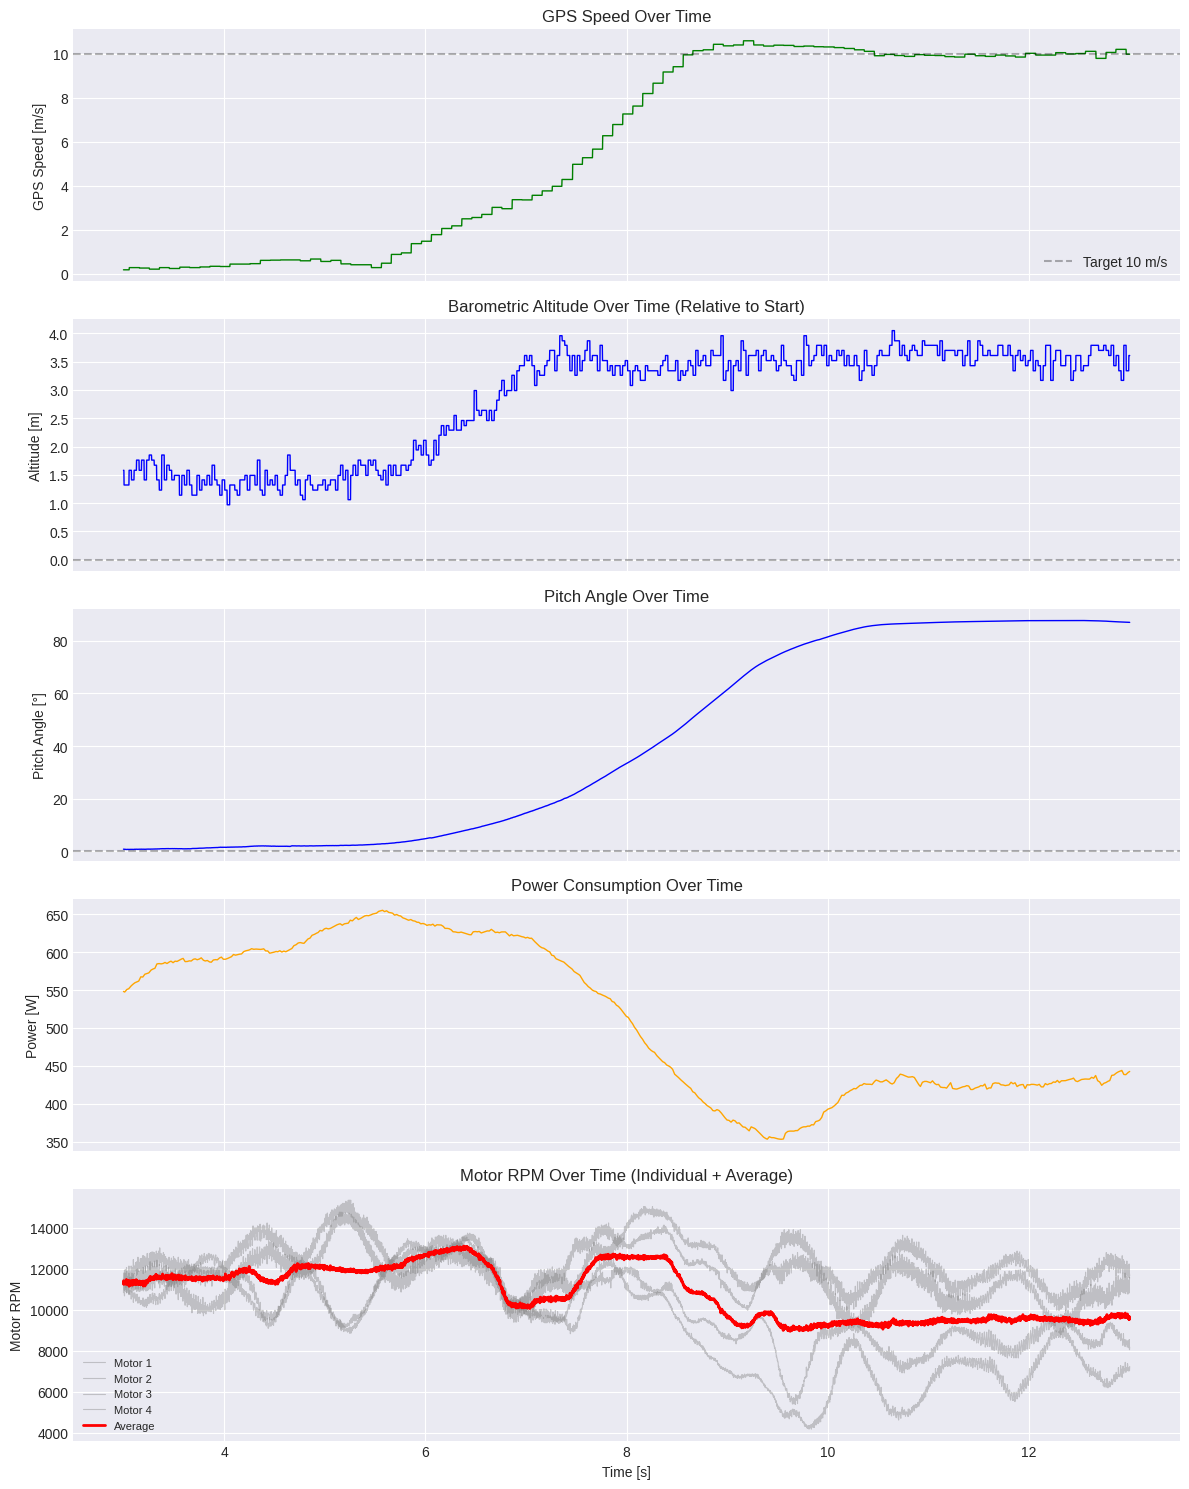

Plot saved to: data/outdoor/speed_pitch_power_rpm_timeseries.png


In [526]:
# Create combined plot with GPS speed, pitch angle, power, motor RPM, and barometric altitude
# Filter data to analysis time range
plot_data = raw_data[(raw_data['time_s'] >= time_start) & (raw_data['time_s'] <= time_end)]

fig, axes = plt.subplots(5, 1, figsize=(12, 15), sharex=True)

# GPS Speed
axes[0].plot(plot_data['time_s'], plot_data['gps_speed_ms'], linewidth=1, color='green')
axes[0].set_ylabel('GPS Speed [m/s]')
axes[0].set_title('GPS Speed Over Time')
axes[0].grid(True)
axes[0].axhline(y=10, color='k', linestyle='--', alpha=0.3, label='Target 10 m/s')
axes[0].legend()

# Barometric Altitude
if 'altitude_rel_m' in plot_data.columns:
    axes[1].plot(plot_data['time_s'], plot_data['altitude_rel_m'], linewidth=1, color='blue')
    axes[1].set_ylabel('Altitude [m]')
    axes[1].set_title('Barometric Altitude Over Time (Relative to Start)')
    axes[1].grid(True)
    axes[1].axhline(y=0, color='k', linestyle='--', alpha=0.3)

# Pitch angle
axes[2].plot(plot_data['time_s'], plot_data['pitch_deg'], linewidth=1, color='blue')
axes[2].set_ylabel('Pitch Angle [°]')
axes[2].set_title('Pitch Angle Over Time')
axes[2].grid(True)
axes[2].axhline(y=0, color='k', linestyle='--', alpha=0.3)

# Power consumption
axes[3].plot(plot_data['time_s'], plot_data['power_W'], linewidth=1, color='orange')
axes[3].set_ylabel('Power [W]')
axes[3].set_title('Power Consumption Over Time')
axes[3].grid(True)

# Average motor RPM
# Plot individual motor RPMs in gray in the background
axes[4].plot(plot_data['time_s'], plot_data['motor1_rpm'], linewidth=0.8, color='gray', alpha=0.4, label='Motor 1')
axes[4].plot(plot_data['time_s'], plot_data['motor2_rpm'], linewidth=0.8, color='gray', alpha=0.4, label='Motor 2')
axes[4].plot(plot_data['time_s'], plot_data['motor3_rpm'], linewidth=0.8, color='gray', alpha=0.4, label='Motor 3')
axes[4].plot(plot_data['time_s'], plot_data['motor4_rpm'], linewidth=0.8, color='gray', alpha=0.4, label='Motor 4')
# Plot average in red on top
axes[4].plot(plot_data['time_s'], plot_data['motor_avg_rpm'], linewidth=2, color='red', label='Average', zorder=5)
axes[4].set_xlabel('Time [s]')
axes[4].set_ylabel('Motor RPM')
axes[4].set_title('Motor RPM Over Time (Individual + Average)')
axes[4].grid(True)
axes[4].legend(loc='best', fontsize=8)

plt.tight_layout()
plt.savefig(output_dir / 'speed_pitch_power_rpm_timeseries.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Plot saved to: {output_dir / 'speed_pitch_power_rpm_timeseries.png'}")


## 12. Export Processed Data

In [527]:
# Export downsampled data for plotting
# Filter data to analysis time range
export_data = raw_data[(raw_data['time_s'] >= time_start) & (raw_data['time_s'] <= time_end)].copy()

downsample_factor = 10  # Keep every Nth point
data_downsampled = export_data.iloc[::downsample_factor].copy()

# Export to CSV
output_file = output_dir / 'outdoor_flight_motor_data.csv'
export_cols = ['time_s', 'motor_avg_rpm', 'motor1_rpm', 'motor2_rpm', 'motor3_rpm', 'motor4_rpm', 
               'pitch_deg', 'roll_deg', 'yaw_deg', 'gps_speed_ms', 'altitude_rel_m',
               'voltage_V', 'current_A', 'power_W']
data_downsampled[export_cols].to_csv(output_file, index=False)

print(f"\nExported processed data to: {output_file}")
print(f"Time range: {time_start}-{time_end} seconds")
print(f"Original data points (full flight): {len(raw_data)}")
print(f"Filtered data points ({time_start}-{time_end}s): {len(export_data)}")
print(f"Downsampled data points: {len(data_downsampled)}")


Exported processed data to: data/outdoor/outdoor_flight_motor_data.csv
Time range: 3-13 seconds
Original data points (full flight): 15931
Filtered data points (3-13s): 4996
Downsampled data points: 500


## 13. Summary Statistics

In [528]:
print("=== Flight Summary ===")
print(f"Duration: {raw_data['time_s'].iloc[-1]:.2f} seconds")

print(f"\nGPS Speed Statistics:")
print(f"  Mean: {raw_data['gps_speed_ms'].mean():.2f} m/s")
print(f"  Median: {raw_data['gps_speed_ms'].median():.2f} m/s")
print(f"  Std: {raw_data['gps_speed_ms'].std():.2f} m/s")
print(f"  Min: {raw_data['gps_speed_ms'].min():.2f} m/s")
print(f"  Max: {raw_data['gps_speed_ms'].max():.2f} m/s")

print(f"\nPitch Angle Statistics:")
print(f"  Mean: {raw_data['pitch_deg'].mean():.2f}°")
print(f"  Median: {raw_data['pitch_deg'].median():.2f}°")
print(f"  Std: {raw_data['pitch_deg'].std():.2f}°")
print(f"  Min: {raw_data['pitch_deg'].min():.2f}°")
print(f"  Max: {raw_data['pitch_deg'].max():.2f}°")

print(f"\nPower Consumption Statistics:")
print(f"  Mean: {raw_data['power_W'].mean():.2f} W")
print(f"  Median: {raw_data['power_W'].median():.2f} W")
print(f"  Std: {raw_data['power_W'].std():.2f} W")
print(f"  Min: {raw_data['power_W'].min():.2f} W")
print(f"  Max: {raw_data['power_W'].max():.2f} W")
print(f"  Mean voltage: {raw_data['voltage_V'].mean():.2f} V")
print(f"  Mean current: {raw_data['current_A'].mean():.2f} A")

print(f"\nMotor RPM Statistics:")
print(f"  Mean: {raw_data['motor_avg_rpm'].mean():.0f} RPM")
print(f"  Median: {raw_data['motor_avg_rpm'].median():.0f} RPM")
print(f"  Std: {raw_data['motor_avg_rpm'].std():.0f} RPM")
print(f"  Min: {raw_data['motor_avg_rpm'].min():.0f} RPM")
print(f"  Max: {raw_data['motor_avg_rpm'].max():.0f} RPM")

# Quartiles for hover/cruise estimation
q25 = raw_data['motor_avg_rpm'].quantile(0.25)
q75 = raw_data['motor_avg_rpm'].quantile(0.75)
print(f"\nMotor RPM Quartiles:")
print(f"  25th percentile: {q25:.0f} RPM")
print(f"  75th percentile: {q75:.0f} RPM")
print(f"\nLikely cruise RPM (lower quartile): ~{q25:.0f} RPM")
print(f"Likely hover RPM (upper quartile): ~{q75:.0f} RPM")

=== Flight Summary ===
Duration: 31.89 seconds

GPS Speed Statistics:
  Mean: 5.21 m/s
  Median: 4.57 m/s
  Std: 4.00 m/s
  Min: 0.01 m/s
  Max: 12.47 m/s

Pitch Angle Statistics:
  Mean: 8.65°
  Median: 1.63°
  Std: 45.51°
  Min: -60.36°
  Max: 87.73°

Power Consumption Statistics:
  Mean: 518.82 W
  Median: 544.05 W
  Std: 129.82 W
  Min: 0.00 W
  Max: 924.77 W
  Mean voltage: 22.42 V
  Mean current: 23.41 A

Motor RPM Statistics:
  Mean: 10691 RPM
  Median: 11504 RPM
  Std: 2073 RPM
  Min: 1846 RPM
  Max: 13754 RPM

Motor RPM Quartiles:
  25th percentile: 9539 RPM
  75th percentile: 11957 RPM

Likely cruise RPM (lower quartile): ~9539 RPM
Likely hover RPM (upper quartile): ~11957 RPM
